# Business Analytics and Visualisation
Assessment 1 — Part 3 (Session 5)

Student ID: s8200703
Dataset: AusiFood_Foodsupplier.xlsx
Software: Python in Jupyter Notebook
Purpose of this notebook

This is a new notebook created specifically for Part 3. The analysis addresses three business questions:

    Does the Category mix vary from city to city?
    How many orders used the credit_card payment method and what percentage of all orders does this represent?
    Which orders have a sold price between 45and552 inclusive?

The notebook follows a reproducible business analytics workflow: import, inspect, clean, transform, analyse, visualise, and interpret.

Only pandas, seaborn, and matplotlib are imported.

## 1. Import the required libraries

pandas is used to import, clean, transform, and analyse the data. seaborn and matplotlib are used to create clear and professional visualisations. Other visual parameters are set for a clean outlook.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")



# 2. Import the AusiFood dataset

A new copy of the Excel workbook is imported for Part 3, as required by the assessment. The main DataFrame is named s8200703 using the student ID.

In [2]:
s8200703 = pd.read_excel("AusiFood_Foodsupplier.xlsx")

print("Dataset imported successfully.")
print(f"Number of rows: {s8200703.shape[0]:,}")
print(f"Number of columns: {s8200703.shape[1]}")

Dataset imported successfully.
Number of rows: 900
Number of columns: 21


## 3. Preview the dataset

The first five observations are displayed to confirm that the workbook loaded correctly. The displayed serial numbers begin at 1 for clearer presentation.

In [3]:
dataset_preview = s8200703.head().copy()

dataset_preview.index = range(
    1,
    len(dataset_preview) + 1
)

dataset_preview.index.name = "Serial Number"

display(dataset_preview)

,Item_id,Item,Category,Store,Supplier,Supplier location,City,Payment method,quantity,Item sold,purchase price,total cost,sold price,Discounts,total sales,Date,Month Number,Month Name,Year,product feedback,other feedback
Serial Number,,,,,,,,,,,,,,,,,,,,,
1,1122,Bulk Almonds 15kg,Bulk & Pantry,Grocery,Mediterranean Wholesalers,VIC,Kensington and Flemington,credit_card,58,57,165.00,"9,570.00",188.10,0.00,"10,721.70",2017-01-02,1,January,2017,neutral,order was as expected
2,1123,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,Tasmania,Northcote,cash,556,556,2.00,"1,112.00",2.86,79.51,"1,510.65",2017-01-02,1,January,2017,strongly disagree,no one responded to my email
3,1124,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,VIC,Northcote,credit_card,1906,1864,2.00,"3,812.00",2.86,186.59,"5,144.45",2017-01-03,1,January,2017,agree,I like your product
4,1125,Cheese,Dairy & Eggs,Home Delivery,First Ray,Australian Capital Territory,Southbank,credit_card,876,834,5.00,"4,380.00",6.37,265.63,"5,046.95",2017-01-06,1,January,2017,agree,I like your product
5,1126,Sour cream,Dairy & Eggs,Home Delivery,Basfoods Direct - Somerton Store,Tasmania,Kensington and Flemington,credit_card,217,202,6.00,"1,302.00",6.60,66.66,"1,266.54",2017-01-10,1,January,2017,neutral,no comment


## 4. Inspect the dataset structure

The info() method is used to review the column names, data types, non-missing observations, and memory usage before beginning the analysis.

In [4]:
s8200703.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Item_id            900 non-null    int64         
 1   Item               900 non-null    object        
 2   Category           900 non-null    object        
 3   Store              900 non-null    object        
 4   Supplier           900 non-null    object        
 5   Supplier location  900 non-null    object        
 6   City               900 non-null    object        
 7   Payment method     900 non-null    object        
 8   quantity           900 non-null    int64         
 9   Item sold          900 non-null    int64         
 10  purchase price     900 non-null    float64       
 11  total cost         900 non-null    float64       
 12  sold price         900 non-null    float64       
 13  Discounts          900 non-null    float64       
 14  total sale

## 5. Check data quality

The dataset is checked for missing values and fully duplicated rows. This step helps determine whether additional cleaning is required before analysis.

In [5]:
data_quality = pd.DataFrame({
    "Check": [
        "Total rows",
        "Total columns",
        "Missing values",
        "Duplicate rows"
    ],
    "Result": [
        len(s8200703),
        s8200703.shape[1],
        int(s8200703.isna().sum().sum()),
        int(s8200703.duplicated().sum())
    ]
})

data_quality.insert(
    0,
    "Serial Number",
    range(1, len(data_quality) + 1)
)

display(
    data_quality.style
    .hide(axis="index")
)

Serial Number,Check,Result
1,Total rows,900
2,Total columns,21
3,Missing values,0
4,Duplicate rows,0


## 6. Create a working DataFrame for Part 3

A separate working DataFrame named s8200703_part3 is created. This preserves the original imported DataFrame while allowing cleaning and transformations to be applied safely.

In [6]:
s8200703_part3 = s8200703.copy()

print("Working DataFrame created successfully.")

Working DataFrame created successfully.


## 7. Clean and standardise text fields

Leading and trailing spaces are removed from the text variables used in Part 3. The payment-method values are also converted to lowercase so that credit_card can be identified consistently.

In [7]:
text_columns = [
    "Item",
    "Category",
    "City",
    "Payment method"
]

for column in text_columns:
    s8200703_part3[column] = (
        s8200703_part3[column]
        .astype(str)
        .str.strip()
    )

s8200703_part3["Payment method"] = (
    s8200703_part3["Payment method"]
    .str.lower()
)

print("Text fields cleaned successfully.")

Text fields cleaned successfully.


## Question 1 — Category Mix by City
8. Identify the Category and City values

Before calculating percentages, the unique categories and cities are identified. This establishes the dimensions used in the category-mix analysis.

In [8]:
unique_categories = sorted(
    s8200703_part3["Category"]
    .dropna()
    .unique()
)

unique_cities = sorted(
    s8200703_part3["City"]
    .dropna()
    .unique()
)

print(f"Number of Categories: {len(unique_categories)}")
print(unique_categories)

print(f"\nNumber of Cities: {len(unique_cities)}")
print(unique_cities)

Number of Categories: 5
['Bulk & Pantry', 'Dairy & Eggs', 'Fruit', 'Meat & Seafood', 'Vegetables']

Number of Cities: 15
['Carlton', 'Docklands', 'East Melbourne', 'Fitzroy', 'Heidelberg', 'Kensington and Flemington', 'North Melbourne', 'Northcote', 'Parkville', 'Port Melbourne', 'Princes Hill', 'Richmond', 'South Yarra - west', 'Southbank', 'West Melbourne']


## 9. Create a raw order-count table by City and Category

The first table counts the number of orders for each Category within each City. This provides the raw frequency data before percentage standardisation.

In [9]:
category_order_counts = pd.crosstab(
    s8200703_part3["City"],
    s8200703_part3["Category"]
)

category_order_counts["Total Orders"] = (
    category_order_counts.sum(axis=1)
)

category_order_counts.index.name = "City"

category_order_counts_display = (
    category_order_counts
    .reset_index()
)

category_order_counts_display.insert(
    0,
    "Serial Number",
    range(1, len(category_order_counts_display) + 1)
)

display(
    category_order_counts_display.style
    .format({
        column: "{:,.0f}"
        for column in category_order_counts_display.columns
        if column not in ["Serial Number", "City"]
    })
    .hide(axis="index")
)

Serial Number,City,Bulk & Pantry,Dairy & Eggs,Fruit,Meat & Seafood,Vegetables,Total Orders
1,Carlton,4,25,4,7,23,63
2,Docklands,9,14,6,11,16,56
3,East Melbourne,7,18,5,4,9,43
4,Fitzroy,16,13,15,7,17,68
5,Heidelberg,11,11,14,4,19,59
6,Kensington and Flemington,8,30,6,6,18,68
7,North Melbourne,8,10,9,7,13,47
8,Northcote,16,39,25,8,50,138
9,Parkville,6,15,6,3,13,43
10,Port Melbourne,6,9,3,9,14,41


## 10. Calculate each City's Category mix as percentages

Cities have different numbers of orders, so raw counts are not directly comparable. Each Category count is divided by that City's total orders and multiplied by 100.

A Total Percentage column is included as a validation check. Every City should sum to approximately 100%.

In [11]:
category_percentage = (
    category_order_counts
    .drop(columns="Total Orders")
    .div(
        category_order_counts["Total Orders"],
        axis=0
    )
    * 100
)

category_percentage = category_percentage.round(1)

category_percentage["Total Percentage"] = (
    category_percentage.sum(axis=1)
).round(1)

category_percentage.index.name = "City"

category_percentage_display = (
    category_percentage
    .reset_index()
)

category_percentage_display.insert(
    0,
    "Serial Number",
    range(1, len(category_percentage_display) + 1)
)

display(
    category_percentage_display.style
    .format({
        column: "{:.1f}%"
        for column in category_percentage_display.columns
        if column not in ["Serial Number", "City"]
    })
    .hide(axis="index")
)

Serial Number,City,Bulk & Pantry,Dairy & Eggs,Fruit,Meat & Seafood,Vegetables,Total Percentage
1,Carlton,6.3%,39.7%,6.3%,11.1%,36.5%,99.9%
2,Docklands,16.1%,25.0%,10.7%,19.6%,28.6%,100.0%
3,East Melbourne,16.3%,41.9%,11.6%,9.3%,20.9%,100.0%
4,Fitzroy,23.5%,19.1%,22.1%,10.3%,25.0%,100.0%
5,Heidelberg,18.6%,18.6%,23.7%,6.8%,32.2%,99.9%
6,Kensington and Flemington,11.8%,44.1%,8.8%,8.8%,26.5%,100.0%
7,North Melbourne,17.0%,21.3%,19.1%,14.9%,27.7%,100.0%
8,Northcote,11.6%,28.3%,18.1%,5.8%,36.2%,100.0%
9,Parkville,14.0%,34.9%,14.0%,7.0%,30.2%,100.1%
10,Port Melbourne,14.6%,22.0%,7.3%,22.0%,34.1%,100.0%


## 11. Visualise the Category mix by City

A 100% stacked bar chart is used because the objective is to compare composition rather than absolute order volume. Each bar represents one City and totals 100%, while each colour represents a different Category.

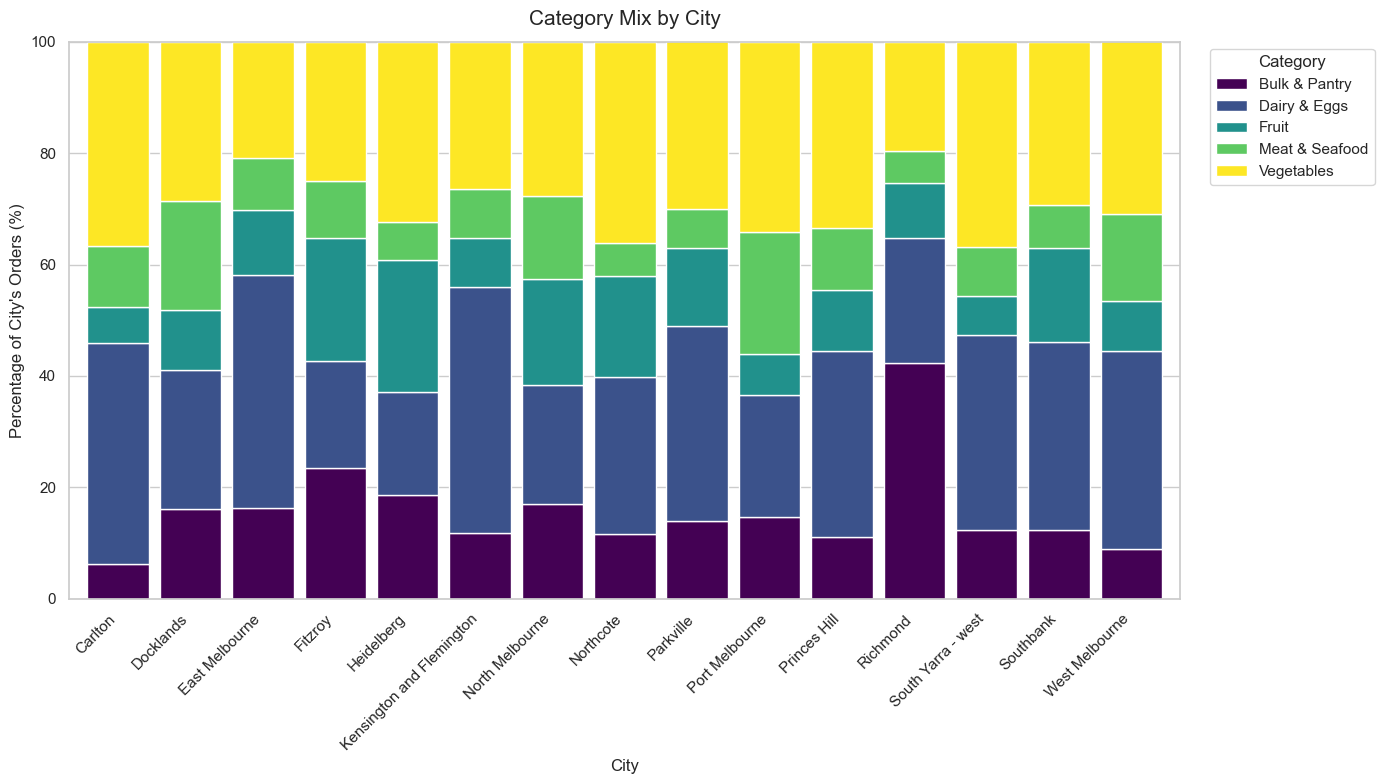

In [12]:
category_chart_data = (
    category_percentage
    .drop(columns="Total Percentage")
)

ax = category_chart_data.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    colormap="viridis",
    width=0.85
)

ax.set_title(
    "Category Mix by City",
    fontsize=15,
    pad=12
)
ax.set_xlabel("City")
ax.set_ylabel("Percentage of City's Orders (%)")
ax.set_ylim(0, 100)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 12. Supporting analysis for Category mix

The dominant Category in each City is identified to make the geographic differences easier to interpret.

In [13]:
category_only = (
    category_percentage
    .drop(columns="Total Percentage")
)

dominant_category = pd.DataFrame({
    "City": category_only.index,
    "Dominant Category": category_only.idxmax(axis=1),
    "Highest Category Percentage": category_only.max(axis=1)
}).reset_index(drop=True)

dominant_category.insert(
    0,
    "Serial Number",
    range(1, len(dominant_category) + 1)
)

display(
    dominant_category.style
    .format({
        "Highest Category Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)

Serial Number,City,Dominant Category,Highest Category Percentage
1,Carlton,Dairy & Eggs,39.7%
2,Docklands,Vegetables,28.6%
3,East Melbourne,Dairy & Eggs,41.9%
4,Fitzroy,Vegetables,25.0%
5,Heidelberg,Vegetables,32.2%
6,Kensington and Flemington,Dairy & Eggs,44.1%
7,North Melbourne,Vegetables,27.7%
8,Northcote,Vegetables,36.2%
9,Parkville,Dairy & Eggs,34.9%
10,Port Melbourne,Vegetables,34.1%


## 13. Discussion — Category Mix by City

The category-mix analysis shows that AusiFood’s order composition varies across cities. Each city was converted to percentages so differences in total order volume did not distort the comparison. Dairy & Eggs dominates Kensington and Flemington at 44.1% and East Melbourne at 41.9%, while Bulk & Pantry is unusually high in Richmond at 42.3%. Vegetables is the largest category in several locations, including South Yarra - west at 36.8%, Carlton at 36.5%, and Northcote at 36.2%. These differences suggest that customer purchasing preferences are not geographically uniform. AusiFood could use these patterns to support city-specific inventory allocation, merchandising, and demand planning.

# Question 2 — Credit Card Orders
14. Identify the unique payment methods

The unique values in Payment method are reviewed before filtering for credit_card.

In [14]:
payment_method_values = (
    s8200703_part3["Payment method"]
    .value_counts()
    .rename_axis("Payment Method")
    .reset_index(name="Number of Orders")
)

payment_method_values["Percentage of All Orders"] = (
    payment_method_values["Number of Orders"]
    / len(s8200703_part3)
    * 100
).round(1)

payment_method_values.insert(
    0,
    "Serial Number",
    range(1, len(payment_method_values) + 1)
)

display(
    payment_method_values.style
    .format({
        "Number of Orders": "{:,.0f}",
        "Percentage of All Orders": "{:.1f}%"
    })
    .hide(axis="index")
)

Serial Number,Payment Method,Number of Orders,Percentage of All Orders
1,credit_card,321,35.7%
2,bank_transfer,196,21.8%
3,debit_card,179,19.9%
4,cash,121,13.4%
5,paypal,83,9.2%


## 15. Filter the orders that used credit_card

A Boolean condition is used to identify only the orders where the customer selected credit_card as the payment method.

In [15]:
credit_card_orders = (
    s8200703_part3
    .loc[
        s8200703_part3["Payment method"] == "credit_card"
    ]
    .copy()
)

print(
    f"Number of credit-card orders: "
    f"{len(credit_card_orders):,}"
)

Number of credit-card orders: 321


## 16. Preview the identified credit-card orders

The first 10 matching orders are displayed as evidence that the filtering condition has been applied correctly. Serial numbers begin at 1 for presentation.

In [16]:
credit_card_preview = (
    credit_card_orders[
        [
            "Item_id",
            "Item",
            "Category",
            "City",
            "Payment method",
            "sold price",
            "total sales",
            "Date"
        ]
    ]
    .head(10)
    .copy()
)

credit_card_preview.index = range(
    1,
    len(credit_card_preview) + 1
)

credit_card_preview.index.name = "Serial Number"

display(
    credit_card_preview.style
    .format({
        "sold price": "${:,.2f}",
        "total sales": "${:,.2f}"
    })
)

,Item_id,Item,Category,City,Payment method,sold price,total sales,Date
Serial Number,,,,,,,,
1,1122,Bulk Almonds 15kg,Bulk & Pantry,Kensington and Flemington,credit_card,$188.10,"$10,721.70",2017-01-02 00:00:00
2,1124,Tomatoes,Vegetables,Northcote,credit_card,$2.86,"$5,144.45",2017-01-03 00:00:00
3,1125,Cheese,Dairy & Eggs,Southbank,credit_card,$6.37,"$5,046.95",2017-01-06 00:00:00
4,1126,Sour cream,Dairy & Eggs,Kensington and Flemington,credit_card,$6.60,"$1,266.54",2017-01-10 00:00:00
5,1128,Wild Salmon,Meat & Seafood,Northcote,credit_card,$20.32,"$53,482.24",2017-01-12 00:00:00
6,1132,Celery,Vegetables,Carlton,credit_card,$5.10,"$11,424.00",2017-01-26 00:00:00
7,1134,Eggs,Dairy & Eggs,Carlton,credit_card,$12.31,"$41,287.74",2017-01-28 00:00:00
8,1144,Organic Cheese Wheel,Bulk & Pantry,East Melbourne,credit_card,$408.75,"$57,225.00",2017-03-08 00:00:00
9,1149,Wild Salmon,Meat & Seafood,Fitzroy,credit_card,$21.16,"$91,601.64",2017-03-25 00:00:00


## 17. Calculate the number and percentage of credit-card orders

The share of all orders is calculated using:

Credit-card percentage = Credit-card orders ÷ Total orders × 100

A Total row is included so the percentage column can be verified against 100%.

In [17]:
total_orders = len(s8200703_part3)
credit_card_count = len(credit_card_orders)
other_order_count = total_orders - credit_card_count

credit_card_percentage = (
    credit_card_count
    / total_orders
    * 100
)

other_order_percentage = (
    other_order_count
    / total_orders
    * 100
)

credit_card_summary = pd.DataFrame({
    "Order Group": [
        "Credit Card",
        "Other Payment Methods",
        "Total"
    ],
    "Number of Orders": [
        credit_card_count,
        other_order_count,
        total_orders
    ],
    "Percentage of All Orders": [
        credit_card_percentage,
        other_order_percentage,
        100.0
    ]
})

credit_card_summary.insert(
    0,
    "Serial Number",
    range(1, len(credit_card_summary) + 1)
)

display(
    credit_card_summary.style
    .format({
        "Number of Orders": "{:,.0f}",
        "Percentage of All Orders": "{:.1f}%"
    })
    .hide(axis="index")
)

Serial Number,Order Group,Number of Orders,Percentage of All Orders
1,Credit Card,321,35.7%
2,Other Payment Methods,579,64.3%
3,Total,900,100.0%


## 18. Visualise payment-method usage

A multicoloured bar chart compares all payment methods. This provides context for the credit-card result and makes it clear whether credit_card is a dominant or minor payment channel.

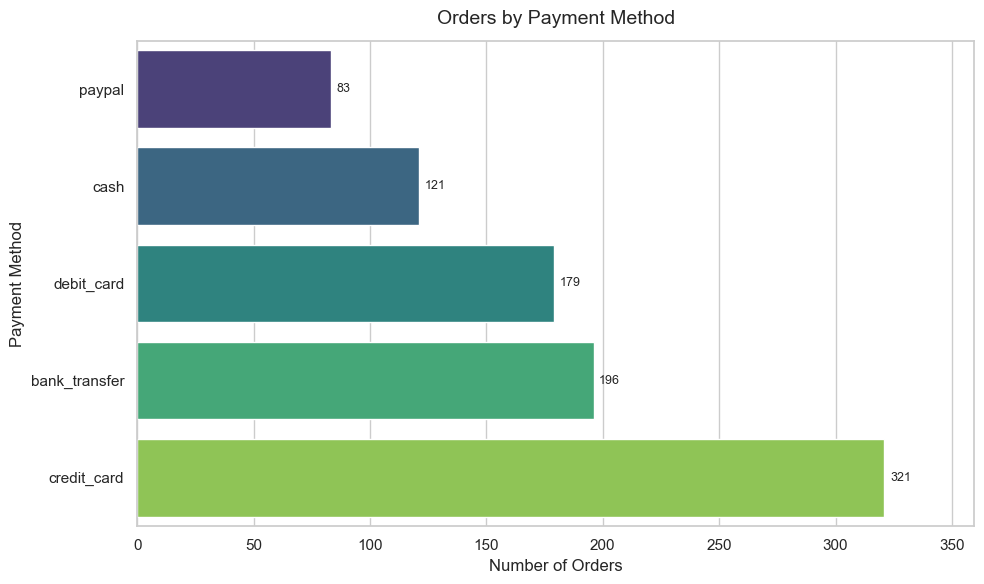

In [18]:
payment_plot = (
    payment_method_values
    .sort_values(
        "Number of Orders",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=payment_plot,
    x="Number of Orders",
    y="Payment Method",
    hue="Payment Method",
    palette="viridis",
    legend=False
)

ax.set_title(
    "Orders by Payment Method",
    fontsize=14,
    pad=12
)
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Payment Method")

for bar in ax.patches:
    width = bar.get_width()

    if pd.notna(width):
        ax.annotate(
            f"{width:,.0f}",
            xy=(
                width,
                bar.get_y() + bar.get_height() / 2
            ),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9
        )

ax.margins(x=0.12)

plt.tight_layout()
plt.show()

## 19. Discussion — Credit Card Orders

The payment-method analysis identifies 321 credit-card orders from 900 total orders, meaning credit cards account for 35.7% of all transactions. This makes credit_card the most frequently used payment method in the dataset, ahead of bank_transfer, debit_card, cash, and PayPal. The result indicates that more than one-third of customers prefer credit cards, suggesting that card-processing reliability is operationally important for AusiFood. However, 64.3% of orders still use other payment methods, so the business should maintain a diverse payment infrastructure rather than optimising only for credit cards. From a business analytics perspective, payment-method share can support decisions about transaction fees, checkout design, fraud controls, and payment-service-provider negotiations. The result should also be interpreted as descriptive rather than causal because the dataset does not explain why customers choose a payment method. Preferences may differ by customer segment, transaction value, city, store, or time period. Further analysis could compare average order value, discounts, and product categories across payment methods to determine whether credit-card customers behave differently from other customers. Tracking these shares over time could also reveal whether payment preferences are changing and whether operational investment should shift toward particular payment channels. This could improve customer convenience while supporting cost-efficient payment operations and planning.

# Question 3 — Sold Price Between \\$45 and \\$552 Inclusive
20. Filter orders using an inclusive sold-price condition

The assessment requires all orders whose sold price is between \\$45 and \\$552 inclusive. The between() method is used with inclusive="both" so that values equal to either boundary would also be included.

In [21]:
price_range_orders = (
    s8200703_part3
    .loc[
        s8200703_part3["sold price"]
        .between(
            45,
            552,
            inclusive="both"
        )
    ]
    .copy()
)

print(
    f"Orders with sold price between "
    f"$45 and $552 inclusive: "
    f"{len(price_range_orders):,}"
)

Orders with sold price between $45 and $552 inclusive: 125


## 21. Preview the identified price-range orders

The first 10 matching observations are displayed to verify the filter. Monetary values are formatted as dollars and serial numbers begin at 1.

In [22]:
price_range_preview = (
    price_range_orders[
        [
            "Item_id",
            "Item",
            "Category",
            "City",
            "sold price",
            "Payment method",
            "Date"
        ]
    ]
    .head(10)
    .copy()
)

price_range_preview.index = range(
    1,
    len(price_range_preview) + 1
)

price_range_preview.index.name = "Serial Number"

display(
    price_range_preview.style
    .format({
        "sold price": "${:,.2f}"
    })
)

,Item_id,Item,Category,City,sold price,Payment method,Date
Serial Number,,,,,,,
1,1122,Bulk Almonds 15kg,Bulk & Pantry,Kensington and Flemington,$188.10,credit_card,2017-01-02 00:00:00
2,1144,Organic Cheese Wheel,Bulk & Pantry,East Melbourne,$408.75,credit_card,2017-03-08 00:00:00
3,1148,Free-Range Beef Quarter,Bulk & Pantry,Kensington and Flemington,$494.00,debit_card,2017-03-24 00:00:00
4,1155,Organic Cheese Wheel,Bulk & Pantry,South Yarra - west,$420.00,credit_card,2017-04-14 00:00:00
5,1163,Organic Coffee Beans 10kg,Bulk & Pantry,North Melbourne,$176.22,credit_card,2017-05-10 00:00:00
6,1166,Wild Salmon Side (whole),Bulk & Pantry,Carlton,$97.85,bank_transfer,2017-05-15 00:00:00
7,1171,Organic Flour 25kg,Bulk & Pantry,East Melbourne,$68.12,debit_card,2017-06-03 00:00:00
8,1172,Organic Flour 25kg,Bulk & Pantry,Northcote,$60.62,cash,2017-06-03 00:00:00
9,1201,Wild Salmon Side (whole),Bulk & Pantry,Docklands,$102.60,bank_transfer,2017-09-01 00:00:00


## 22. Summarise the filtered price-range orders

The summary reports the number of filtered orders, their percentage of all orders, and descriptive sold-price statistics. A Total row confirms the overall percentage denominator.

In [24]:
price_range_count = len(price_range_orders)

price_range_percentage = (
    price_range_count
    / total_orders
    * 100
)

price_range_summary = pd.DataFrame({
    "Measure": [
        "Orders between \\$45 and \\$552",
        "Orders outside the range",
        "Total orders"
    ],
    "Number of Orders": [
        price_range_count,
        total_orders - price_range_count,
        total_orders
    ],
    "Percentage of All Orders": [
        price_range_percentage,
        100 - price_range_percentage,
        100.0
    ]
})

price_range_summary.insert(
    0,
    "Serial Number",
    range(1, len(price_range_summary) + 1)
)

display(
    price_range_summary.style
    .format({
        "Number of Orders": "{:,.0f}",
        "Percentage of All Orders": "{:.1f}%"
    })
    .hide(axis="index")
)

price_statistics = pd.DataFrame({
    "Statistic": [
        "Minimum sold price",
        "Median sold price",
        "Mean sold price",
        "Maximum sold price"
    ],
    "Value": [
        price_range_orders["sold price"].min(),
        price_range_orders["sold price"].median(),
        price_range_orders["sold price"].mean(),
        price_range_orders["sold price"].max()
    ]
})

price_statistics.insert(
    0,
    "Serial Number",
    range(1, len(price_statistics) + 1)
)

display(
    price_statistics.style
    .format({
        "Value": "${:,.2f}"
    })
    .hide(axis="index")
)

Serial Number,Measure,Number of Orders,Percentage of All Orders
1,Orders between \$45 and \$552,125,13.9%
2,Orders outside the range,775,86.1%
3,Total orders,900,100.0%


Serial Number,Statistic,Value
1,Minimum sold price,$59.81
2,Median sold price,$201.56
3,Mean sold price,$217.34
4,Maximum sold price,$548.08


## 23. Visualise the filtered sold-price distribution

A multicoloured stacked histogram shows the distribution of sold prices within the required range and also identifies which product Categories contribute to different price levels.

In [28]:
display(
    price_range_orders[
        [
            "Item",
            "Category",
            "City",
            "sold price",
            "Payment method"
        ]
    ]
    .reset_index(drop=True)
    .set_axis(
        range(1, len(price_range_orders) + 1),
        axis="index"
    )
    .style
    .format(
        {
            "sold price": "${:,.2f}"
        }
    )
)

,Item,Category,City,sold price,Payment method
1,Bulk Almonds 15kg,Bulk & Pantry,Kensington and Flemington,$188.10,credit_card
2,Organic Cheese Wheel,Bulk & Pantry,East Melbourne,$408.75,credit_card
3,Free-Range Beef Quarter,Bulk & Pantry,Kensington and Flemington,$494.00,debit_card
4,Organic Cheese Wheel,Bulk & Pantry,South Yarra - west,$420.00,credit_card
5,Organic Coffee Beans 10kg,Bulk & Pantry,North Melbourne,$176.22,credit_card
6,Wild Salmon Side (whole),Bulk & Pantry,Carlton,$97.85,bank_transfer
7,Organic Flour 25kg,Bulk & Pantry,East Melbourne,$68.12,debit_card
8,Organic Flour 25kg,Bulk & Pantry,Northcote,$60.62,cash
9,Wild Salmon Side (whole),Bulk & Pantry,Docklands,$102.60,bank_transfer
10,Extra Virgin Olive Oil 20L,Bulk & Pantry,Northcote,$217.28,bank_transfer


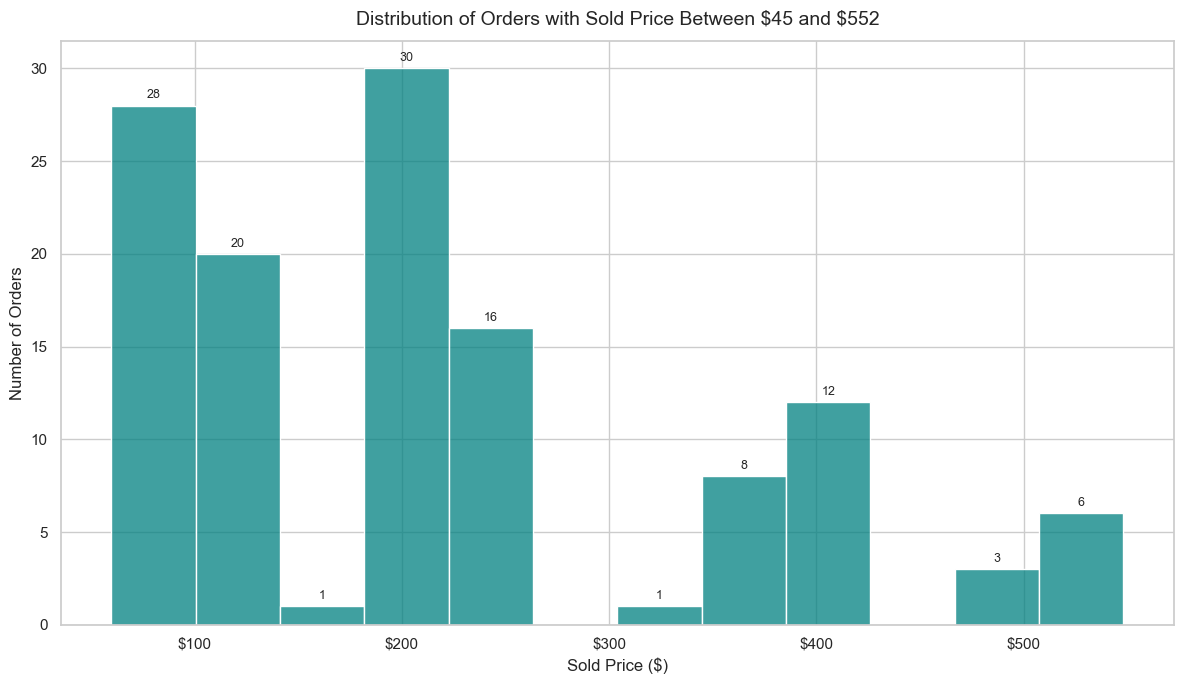

In [30]:
plt.figure(figsize=(12, 7))

ax = sns.histplot(
    data=price_range_orders,
    x="sold price",
    bins=12,
    color="teal",
    edgecolor="white"
)

ax.set_title(
    "Distribution of Orders with Sold Price Between \\$45 and \\$552",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Sold Price ($)")
ax.set_ylabel("Number of Orders")

# Format x-axis as dollar values
ax.xaxis.set_major_formatter(
    lambda value, position: f"${value:,.0f}"
)

# Add order-count labels above each histogram bar
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:
        ax.annotate(
            f"{height:.0f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 24. Identify the most common products in the filtered range

The most frequently occurring products in the selected price interval are calculated to support the interpretation of the visualisation.

Serial Number,Item,Number of Orders
1,Bulk Almonds 15kg,20
2,Organic Flour 25kg,18
3,Wild Salmon Side (whole),17
4,Extra Virgin Olive Oil 20L,15
5,Organic Cheese Wheel,13
6,Organic Rice 50kg,13
7,Organic Coffee Beans 10kg,12
8,Free-Range Beef Quarter,9
9,Manuka Honey Case (12),8


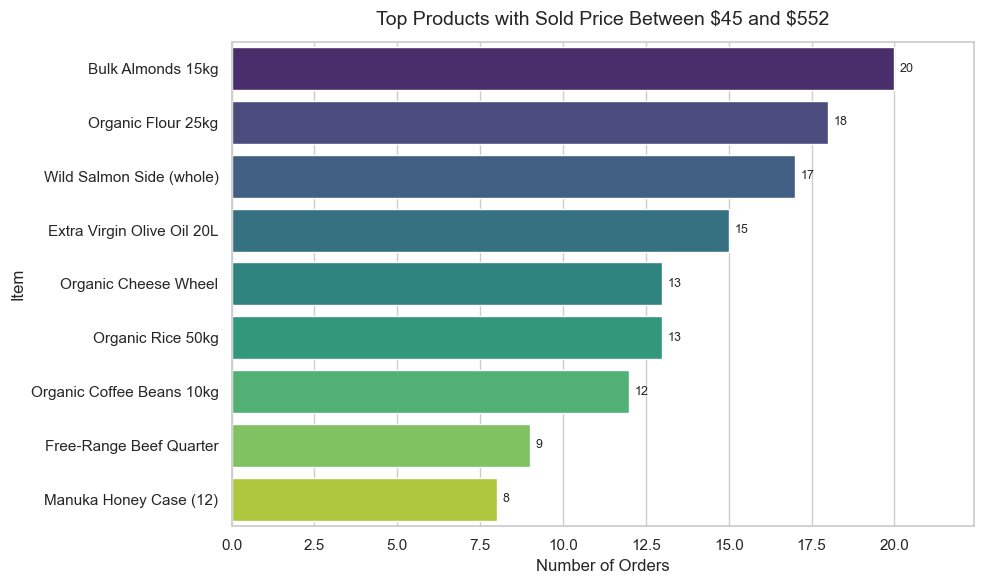

In [34]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_price_range_items,
    x="Number of Orders",
    y="Item",
    hue="Item",
    palette="viridis",
    legend=False
)

ax.set_title(
    "Top Products with Sold Price Between \\$45 and \\$552",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Number of Orders")
ax.set_ylabel("Item")

# Add value labels
for bar in ax.patches:
    width = bar.get_width()

    if pd.notna(width):
        ax.annotate(
            f"{width:.0f}",
            xy=(
                width,
                bar.get_y() + bar.get_height() / 2
            ),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9
        )

ax.margins(x=0.12)

plt.tight_layout()
plt.show()

## 25. Discussion — Sold Price Between \\$45 and \\$552

The inclusive sold-price filter identifies 125 orders priced between \\$45 and \\$552, representing 13.9% of all 900 orders. Prices within this subset range from \\$59.81 to \\$548.08, with a median of approximately \\$201.56. The filtered orders are concentrated in higher-priced bulk and premium products, including Bulk Almonds 15kg, Organic Flour 25kg, Wild Salmon Side, Extra Virgin Olive Oil 20L, and Organic Cheese Wheel. This indicates that the selected price interval captures a relatively small but commercially significant high-value segment. AusiFood could analyse these orders further by revenue, margin, city, and category to understand their contribution to profitability and strategic value.